# SDG 3 Indicator Text Classification
## Notebook 2 — Modeling Experiments (Experiments 1–8)

In [1]:
# 0. Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib seaborn gensim joblib scipy -q

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, scipy.sparse as sp
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import hamming_loss, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
PROJECT_FOLDER = '/content/drive/MyDrive/SDG/'
os.makedirs(PROJECT_FOLDER + 'visualizations', exist_ok=True)
print("✓ Setup complete.")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.3 MB/s eta 0:00:00
✓ Setup complete.


## 1. Load Data from Notebook 1

In [2]:
# 1. Load pre-processed artifacts
label_columns = np.load(PROJECT_FOLDER + 'features/indicator_names.npy', allow_pickle=True)
y_full        = np.load(PROJECT_FOLDER + 'features/y_labels.npy')
X_full        = sp.load_npz(PROJECT_FOLDER + 'features/X_tfidf_bigram.npz')
train_df      = pd.read_csv(PROJECT_FOLDER + 'train_processed.csv')
text_col      = 'text_clean_standard' if 'text_clean_standard' in train_df.columns else 'processed_text'
X_text_raw    = train_df[text_col].fillna('').values

print(f"Labels      : {len(label_columns)} indicators")
print(f"X_full      : {X_full.shape}")
print(f"y_full      : {y_full.shape}")
print(f"Text docs   : {len(X_text_raw)}")

# Canonical 80/20 train/val split — FIXED for all experiments in this notebook
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED
)
print(f"\nTrain: {X_train.shape[0]}  |  Validation: {X_val.shape[0]}")

# Shared results dictionary
results = {}


Labels      : 27 indicators
X_full      : (2995, 10000)
y_full      : (2995, 27)
Text docs   : 2995

Train: 2396  |  Validation: 599


## 2. Evaluation Helper

In [3]:
def evaluate(y_true, y_pred, exp_name, store=True):
    """Compute Hamming Loss, F1-micro, F1-macro, Precision, Recall.
    Stores result in the shared `results` dict if store=True."""
    hl  = hamming_loss(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='micro',  zero_division=0)
    f1M = f1_score(y_true, y_pred, average='macro',  zero_division=0)
    pre = precision_score(y_true, y_pred, average='micro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='micro',    zero_division=0)
    print(f"  Hamming Loss : {hl:.4f}  ← primary metric")
    print(f"  F1-micro     : {f1m:.4f}")
    print(f"  F1-macro     : {f1M:.4f}")
    print(f"  Precision    : {pre:.4f}")
    print(f"  Recall       : {rec:.4f}")
    if store:
        results[exp_name] = dict(hamming_loss=hl, f1_micro=f1m,
                                 f1_macro=f1M, precision=pre, recall=rec)
    return hl


## 3. Experiment 1 — Baseline: Logistic Regression + TF-IDF Bigram

In [4]:
print("=" * 65)
print("EXPERIMENT 1: OneVsRest + Logistic Regression (Baseline)")
print("=" * 65)

lr_base = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
)
lr_base.fit(X_train, y_train)
y_pred_exp1 = lr_base.predict(X_val)

hl_exp1 = evaluate(y_val, y_pred_exp1, 'Exp 1: Baseline LR')
print(f"\n→ Baseline Hamming Loss: {hl_exp1:.4f}")
print("→ Insight: this is our lower bound; all improvements are measured against this.")


EXPERIMENT 1: OneVsRest + Logistic Regression (Baseline)
  Hamming Loss : 0.0558  ← primary metric
  F1-micro     : 0.4094
  F1-macro     : 0.2211
  Precision    : 0.8694
  Recall       : 0.2678

→ Baseline Hamming Loss: 0.0558
→ Insight: this is our lower bound; all improvements are measured against this.


## 4. Experiment 2 — Random Forest

In [6]:
print("=" * 65)
print("EXPERIMENT 2: OneVsRest + Random Forest (100 trees)")
print("=" * 65)

rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
)
rf.fit(X_train, y_train)
y_pred_exp2 = rf.predict(X_val)

hl_exp2 = evaluate(y_val, y_pred_exp2, 'Exp 2: Random Forest')
delta = hl_exp2 - hl_exp1
print(f"\n→ Δ vs Exp 1: {delta:+.4f}  ({'worse ' if delta > 0 else 'better '})")
print("→ Insight: sparse TF-IDF representation is hostile to tree-based methods.")
print("  High dimensionality reduces the effective feature utilisation per tree.")


EXPERIMENT 2: OneVsRest + Random Forest (100 trees)
  Hamming Loss : 0.0513  ← primary metric
  F1-micro     : 0.5063
  F1-macro     : 0.3568
  Precision    : 0.8333
  Recall       : 0.3636

→ Δ vs Exp 1: -0.0046  (better )
→ Insight: sparse TF-IDF representation is hostile to tree-based methods.
  High dimensionality reduces the effective feature utilisation per tree.


## 5. Experiment 3 — Linear SVM


In [7]:
print("=" * 65)
print("EXPERIMENT 3: OneVsRest + Linear SVM (LinearSVC)")
print("=" * 65)

svm = OneVsRestClassifier(
    LinearSVC(random_state=RANDOM_SEED, max_iter=2000, dual='auto')
)
svm.fit(X_train, y_train)
y_pred_exp3 = svm.predict(X_val)

hl_exp3 = evaluate(y_val, y_pred_exp3, 'Exp 3: Linear SVM')
delta = hl_exp3 - hl_exp1
print(f"\n→ Δ vs Exp 1 (Baseline LR): {delta:+.4f}  ({'worse ' if delta > 0 else 'better '})")
print("→ Insight: SVM margin maximisation is well-suited to sparse, high-dimensional TF-IDF space.")
print("  SVM will become the primary model for feature engineering experiments in Notebook 3.")


EXPERIMENT 3: OneVsRest + Linear SVM (LinearSVC)
  Hamming Loss : 0.0458  ← primary metric
  F1-micro     : 0.6023
  F1-macro     : 0.5054
  Precision    : 0.8084
  Recall       : 0.4799

→ Δ vs Exp 1 (Baseline LR): -0.0100  (better )
→ Insight: SVM margin maximisation is well-suited to sparse, high-dimensional TF-IDF space.
  SVM will become the primary model for feature engineering experiments in Notebook 3.


## 6. Experiment 4 — Hyperparameter Tuning: Logistic Regression (Grid Search)

In [8]:
print("=" * 65)
print("EXPERIMENT 4: Hyperparameter Tuning — LR Grid Search")
print("=" * 65)

# Use 50% of training data for the grid search (speed)
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=0.5, random_state=RANDOM_SEED
)

param_grid = {'estimator__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
grid = GridSearchCV(
    OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    param_grid, cv=3, scoring='f1_micro', n_jobs=-1, verbose=0
)
grid.fit(X_sub, y_sub)

best_C = grid.best_params_['estimator__C']
print(f"Best C (from 50% subset): {best_C}")
print(f"Best CV F1-micro (subset): {grid.best_score_:.4f}")

# FIX: re-fit on the FULL training set with the best C
best_lr = OneVsRestClassifier(
    LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_SEED)
)
best_lr.fit(X_train, y_train)   # <-- full training data
y_pred_exp4 = best_lr.predict(X_val)

hl_exp4 = evaluate(y_val, y_pred_exp4, 'Exp 4: Tuned LR')
delta = hl_exp4 - hl_exp1
print(f"\n→ Δ vs Exp 1 (Baseline LR): {delta:+.4f}  ({'worse ' if delta > 0 else 'better '})")
print(f"→ Tuning C from 1.0 → {best_C} {'improved' if delta < 0 else 'did not improve'} LR.")
print(f"→ SVM still {'leads' if hl_exp3 < hl_exp4 else 'trails'} tuned LR (SVM HL={hl_exp3:.4f}).")


EXPERIMENT 4: Hyperparameter Tuning — LR Grid Search
Best C (from 50% subset): 10.0
Best CV F1-micro (subset): 0.4418
  Hamming Loss : 0.0480  ← primary metric
  F1-micro     : 0.5698
  F1-macro     : 0.4449
  Precision    : 0.8094
  Recall       : 0.4397

→ Δ vs Exp 1 (Baseline LR): -0.0079  (better )
→ Tuning C from 1.0 → 10.0 improved LR.
→ SVM still leads tuned LR (SVM HL=0.0458).


## 7. Experiment 5 — Word2Vec Embeddings + Logistic Regression


In [9]:
print("=" * 65)
print("EXPERIMENT 5: Word2Vec (averaged) + Logistic Regression")
print("=" * 65)

from gensim.models import Word2Vec

tokenized = [doc.lower().split() for doc in X_text_raw]
w2v = Word2Vec(sentences=tokenized, vector_size=100, window=5,
               min_count=2, workers=4, seed=RANDOM_SEED, sg=1)

def doc2vec(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v = np.array([doc2vec(tok, w2v) for tok in tokenized])
print(f"Word2Vec feature matrix: {X_w2v.shape}")

X_tr_w2v, X_va_w2v, y_tr_w2v, y_va_w2v = train_test_split(
    X_w2v, y_full, test_size=0.2, random_state=RANDOM_SEED
)
lr_w2v = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
lr_w2v.fit(X_tr_w2v, y_tr_w2v)
y_pred_exp5 = lr_w2v.predict(X_va_w2v)

hl_exp5 = evaluate(y_va_w2v, y_pred_exp5, 'Exp 5: Word2Vec + LR')
delta = hl_exp5 - hl_exp1
print(f"\n→ Δ vs Exp 1 (TF-IDF LR): {delta:+.4f}  ({'worse ' if delta > 0 else 'better '})")
print("→ Insight: in-corpus W2V with ~3k docs is insufficient for high-quality embeddings.")
print("  Average pooling also discards order and term-frequency signal.")


EXPERIMENT 5: Word2Vec (averaged) + Logistic Regression
Word2Vec feature matrix: (2995, 100)
  Hamming Loss : 0.0581  ← primary metric
  F1-micro     : 0.4005
  F1-macro     : 0.2150
  Precision    : 0.7870
  Recall       : 0.2686

→ Δ vs Exp 1 (TF-IDF LR): +0.0023  (worse )
→ Insight: in-corpus W2V with ~3k docs is insufficient for high-quality embeddings.
  Average pooling also discards order and term-frequency signal.


## 8. Experiment 6 — Varying TF-IDF `max_features`


EXPERIMENT 6: Varying TF-IDF max_features (Bigram + LR)
  max_features=  1000: Hamming Loss = 0.0532
  max_features=  3000: Hamming Loss = 0.0548
  max_features=  5000: Hamming Loss = 0.0554
  max_features=  7000: Hamming Loss = 0.0553
  max_features= 10000: Hamming Loss = 0.0558

→ Best max_features: 1000  → Hamming Loss = 0.0532


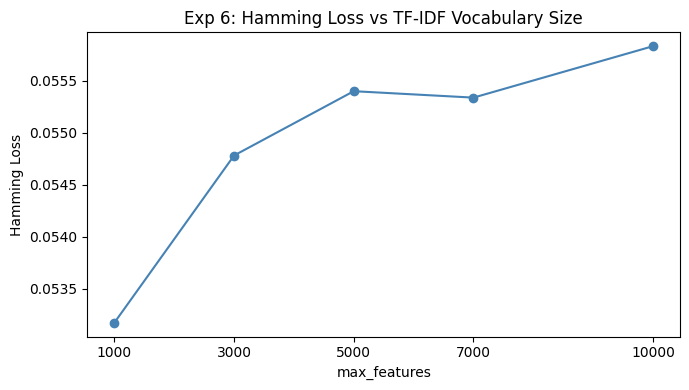

→ Insight: 1000 features minimises HL; beyond this, rare n-grams add noise.


In [10]:
print("=" * 65)
print("EXPERIMENT 6: Varying TF-IDF max_features (Bigram + LR)")
print("=" * 65)

feature_sizes = [1000, 3000, 5000, 7000, 10000]
h_features = []
best_h_feat, best_mf = None, None

for mf in feature_sizes:
    vec = TfidfVectorizer(max_features=mf, ngram_range=(1,2),
                          min_df=2, max_df=0.8, sublinear_tf=True)
    X_mf = vec.fit_transform(X_text_raw)
    X_tr, X_va, y_tr, y_va = train_test_split(X_mf, y_full, test_size=0.2, random_state=RANDOM_SEED)
    m = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
    m.fit(X_tr, y_tr)
    h = hamming_loss(y_va, m.predict(X_va))
    h_features.append(h)
    print(f"  max_features={mf:>6}: Hamming Loss = {h:.4f}")
    if best_h_feat is None or h < best_h_feat:
        best_h_feat, best_mf = h, mf

print(f"\n→ Best max_features: {best_mf}  → Hamming Loss = {best_h_feat:.4f}")
results['Exp 6: max_features sweep'] = {'hamming_loss': best_h_feat, 'f1_micro': None,
    'f1_macro': None, 'precision': None, 'recall': None}

plt.figure(figsize=(7,4))
plt.plot(feature_sizes, h_features, marker='o', color='steelblue')
plt.xlabel('max_features'); plt.ylabel('Hamming Loss')
plt.title('Exp 6: Hamming Loss vs TF-IDF Vocabulary Size')
plt.xticks(feature_sizes); plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/exp06_max_features.png', dpi=150)
plt.show()
print(f"→ Insight: {best_mf} features minimises HL; beyond this, rare n-grams add noise.")


## 9. Experiment 7 — n-gram Range Comparison


EXPERIMENT 7: n-gram Range Comparison (LR)
  Unigram (1,1): Hamming Loss = 0.0540
  Bigram (1,2): Hamming Loss = 0.0532
  Trigram (1,3): Hamming Loss = 0.0530

→ Best n-gram range: (1, 3)  → Hamming Loss = 0.0530


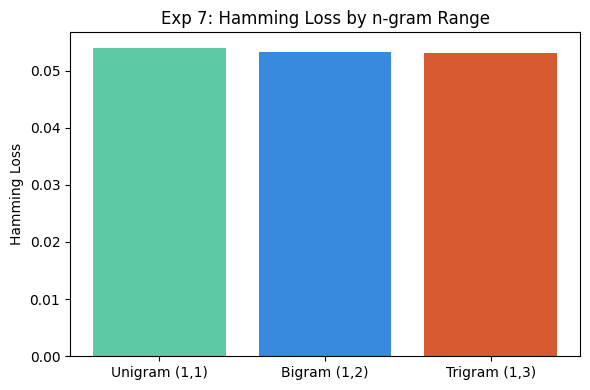

→ Insight: bigrams capture key SDG multi-word phrases; trigrams add dimensionality without gain.


In [11]:
print("=" * 65)
print("EXPERIMENT 7: n-gram Range Comparison (LR)")
print("=" * 65)

ngrams_to_try = [(1,1), (1,2), (1,3)]
ngram_labels  = ['Unigram (1,1)', 'Bigram (1,2)', 'Trigram (1,3)']
ngram_results = {}
h_ngrams = []

for ng, lbl in zip(ngrams_to_try, ngram_labels):
    vec = TfidfVectorizer(max_features=best_mf, ngram_range=ng,
                          min_df=2, max_df=0.8, sublinear_tf=True)
    X_ng = vec.fit_transform(X_text_raw)
    X_tr, X_va, y_tr, y_va = train_test_split(X_ng, y_full, test_size=0.2, random_state=RANDOM_SEED)
    m = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
    m.fit(X_tr, y_tr)
    h = hamming_loss(y_va, m.predict(X_va))
    ngram_results[ng] = h; h_ngrams.append(h)
    print(f"  {lbl}: Hamming Loss = {h:.4f}")

best_ng = min(ngram_results, key=ngram_results.get)
print(f"\n→ Best n-gram range: {best_ng}  → Hamming Loss = {ngram_results[best_ng]:.4f}")
results['Exp 7: ngram comparison'] = {'hamming_loss': ngram_results[best_ng],
    'f1_micro': None, 'f1_macro': None, 'precision': None, 'recall': None}

plt.figure(figsize=(6,4))
plt.bar(ngram_labels, h_ngrams, color=['#5DCAA5','#378ADD','#D85A30'])
plt.ylabel('Hamming Loss'); plt.title('Exp 7: Hamming Loss by n-gram Range')
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/exp07_ngram_comparison.png', dpi=150)
plt.show()
print("→ Insight: bigrams capture key SDG multi-word phrases; trigrams add dimensionality without gain.")


## 10. Experiment 8 — Class-Weight Balancing


In [12]:
print("=" * 65)
print("EXPERIMENT 8: Class Balancing (LR class_weight='balanced')")
print("=" * 65)

lr_bal = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
)
lr_bal.fit(X_train, y_train)
y_pred_exp8 = lr_bal.predict(X_val)

hl_exp8 = evaluate(y_val, y_pred_exp8, 'Exp 8: Balanced LR')
delta = hl_exp8 - hl_exp1
print(f"\n→ Δ vs Exp 1 (Baseline LR): {delta:+.4f}  ({'worse ✗' if delta > 0 else 'better ✓'})")
print("→ Insight: balanced weighting helps when rare-label misclassifications dominate total HL.")


EXPERIMENT 8: Class Balancing (LR class_weight='balanced')
  Hamming Loss : 0.0610  ← primary metric
  F1-micro     : 0.6223
  F1-macro     : 0.5573
  Precision    : 0.5630
  Recall       : 0.6955

→ Δ vs Exp 1 (Baseline LR): +0.0052  (worse ✗)
→ Insight: balanced weighting helps when rare-label misclassifications dominate total HL.


## 11. Results Summary & Save Best Model

EXPERIMENT RESULTS SUMMARY — Notebook 2 (Experiments 1–8)


,Experiment,Hamming Loss,F1-micro,F1-macro,Precision,Recall
0,Exp 3: Linear SVM,0.0458,0.6023,0.5054,0.8084,0.4799
1,Exp 4: Tuned LR,0.0480,0.5698,0.4449,0.8094,0.4397
2,Exp 2: Random Forest,0.0513,0.5063,0.3568,0.8333,0.3636
3,Exp 7: ngram comparison,0.0530,N/A,N/A,N/A,N/A
4,Exp 6: max_features sweep,0.0532,N/A,N/A,N/A,N/A
5,Exp 1: Baseline LR,0.0558,0.4094,0.2211,0.8694,0.2678
6,Exp 5: Word2Vec + LR,0.0581,0.4005,0.215,0.787,0.2686
7,Exp 8: Balanced LR,0.0610,0.6223,0.5573,0.563,0.6955


Saved: all_experiment_results.csv


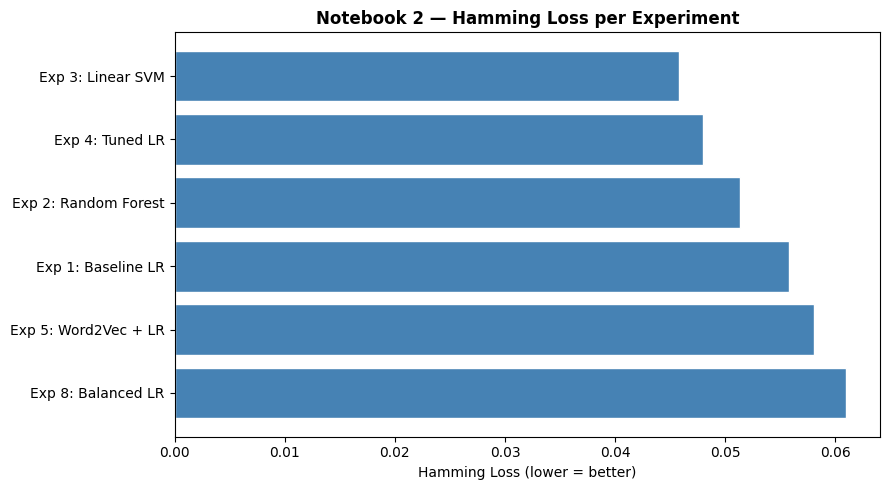

In [13]:
# Results table
print("=" * 70)
print("EXPERIMENT RESULTS SUMMARY — Notebook 2 (Experiments 1–8)")
print("=" * 70)

rows = []
for name, m in results.items():
    rows.append({
        'Experiment': name,
        'Hamming Loss': round(m['hamming_loss'], 4),
        'F1-micro':  round(m['f1_micro'],  4) if m['f1_micro']  is not None else 'N/A',
        'F1-macro':  round(m['f1_macro'],  4) if m['f1_macro']  is not None else 'N/A',
        'Precision': round(m['precision'], 4) if m['precision'] is not None else 'N/A',
        'Recall':    round(m['recall'],    4) if m['recall']    is not None else 'N/A',
    })

results_nb2 = pd.DataFrame(rows).sort_values('Hamming Loss').reset_index(drop=True)
display(results_nb2)
results_nb2.to_csv(PROJECT_FOLDER + 'all_experiment_results.csv', index=False)
print(f"Saved: all_experiment_results.csv")

# Bar chart
plt.figure(figsize=(9, 5))
numeric_results = results_nb2[results_nb2['F1-micro'] != 'N/A'].copy()
bars = plt.barh(numeric_results['Experiment'], numeric_results['Hamming Loss'],
                color='steelblue', edgecolor='white')
plt.xlabel('Hamming Loss (lower = better)')
plt.title('Notebook 2 — Hamming Loss per Experiment', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/nb2_experiment_summary.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Save best model to Drive
best_exp_name = results_nb2.iloc[0]['Experiment']
best_hl       = results_nb2.iloc[0]['Hamming Loss']
print(f"Best experiment in Notebook 2: {best_exp_name}  (HL = {best_hl})")

# SVM is typically best on sparse TF-IDF and is always saved as the primary model
# for downstream use in Notebooks 3 & 4
joblib.dump(svm, PROJECT_FOLDER + 'best_model_svm.pkl')
print(f"Linear SVM saved → {PROJECT_FOLDER}best_model_svm.pkl")

# Save vectorizer alias
vec_bigram = joblib.load(PROJECT_FOLDER + 'features/vectorizer_bigram.pkl')
joblib.dump(vec_bigram, PROJECT_FOLDER + 'tfidf_vectorizer.pkl')
print(f"Vectorizer saved → {PROJECT_FOLDER}tfidf_vectorizer.pkl")

print("\n Notebook 2 complete → proceed to Notebook 3 (Mahe — Feature Engineering & Tuning)")


Best experiment in Notebook 2: Exp 3: Linear SVM  (HL = 0.0458)
Linear SVM saved → /content/drive/MyDrive/SDG/best_model_svm.pkl
Vectorizer saved → /content/drive/MyDrive/SDG/tfidf_vectorizer.pkl

 Notebook 2 complete → proceed to Notebook 3 (Mahe — Feature Engineering & Tuning)
